## BREAST CANCER MODELS  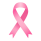

In [4]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from values.cleaning import prepare_data

In [ ]:
import os
import joblib


os.makedirs("models", exist_ok=True)


joblib.dump(best_model, "models/random_forest.pkl")

print("Modelo guardado correctamente")

Modelo guardado correctamente


In [8]:
import pandas as pd 
df = pd.read_csv(
    "../data/breast+cancer+wisconsin+diagnostic/wdbc.data",
    header=None
)

In [10]:
# asignar columnas primero
column_names = ["id", "diagnosis"] + [f"feature_{i}" for i in range(1,31)]
df.columns = column_names

df, le = prepare_data(df)

In [11]:
#SPLIT 
from values.functions import split_data

X_train, X_test, y_train, y_test = split_data(df)

In [12]:
X_train.shape, X_test.shape

((455, 30), (114, 30))

# RANDOM FOREST

In [13]:
from sklearn.ensemble import RandomForestClassifier
from values.functions import train_model, evaluate_model

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf = train_model(rf, X_train, y_train)

metrics_rf, cm_rf = evaluate_model(rf, X_test, y_test)

metrics_rf

{'accuracy': 0.9649122807017544,
 'precision': 1.0,
 'recall': 0.9047619047619048,
 'f1_score': 0.95}

# DECISION TREE

In [14]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt = train_model(dt, X_train, y_train)

metrics_dt, cm_dt = evaluate_model(dt, X_test, y_test)

metrics_dt

{'accuracy': 0.9298245614035088,
 'precision': 0.9047619047619048,
 'recall': 0.9047619047619048,
 'f1_score': 0.9047619047619048}

# KNN 

In [15]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn = train_model(knn, X_train, y_train)

metrics_knn, cm_knn = evaluate_model(knn, X_test, y_test)

metrics_knn

{'accuracy': 0.9122807017543859,
 'precision': 0.9705882352941176,
 'recall': 0.7857142857142857,
 'f1_score': 0.868421052631579}

# GRADIENT BOSTING

In [16]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb = train_model(gb, X_train, y_train)

metrics_gb, cm_gb = evaluate_model(gb, X_test, y_test)

metrics_gb

{'accuracy': 0.9649122807017544,
 'precision': 1.0,
 'recall': 0.9047619047619048,
 'f1_score': 0.95}

# COMPARACION 

In [17]:
results = {
    "Decision Tree": metrics_dt,
    "Random Forest": metrics_rf,
    "KNN": metrics_knn,
    "Gradient Boosting": metrics_gb
}

results

{'Decision Tree': {'accuracy': 0.9298245614035088,
  'precision': 0.9047619047619048,
  'recall': 0.9047619047619048,
  'f1_score': 0.9047619047619048},
 'Random Forest': {'accuracy': 0.9649122807017544,
  'precision': 1.0,
  'recall': 0.9047619047619048,
  'f1_score': 0.95},
 'KNN': {'accuracy': 0.9122807017543859,
  'precision': 0.9705882352941176,
  'recall': 0.7857142857142857,
  'f1_score': 0.868421052631579},
 'Gradient Boosting': {'accuracy': 0.9649122807017544,
  'precision': 1.0,
  'recall': 0.9047619047619048,
  'f1_score': 0.95}}

# CROOS VALIDATION

In [18]:
from sklearn.model_selection import cross_val_score
import numpy as np

In [19]:
rf = RandomForestClassifier(random_state=42)

cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("F1 CV scores:", cv_scores)
print("Mean F1:", np.mean(cv_scores))

F1 CV scores: [1.         0.98507463 0.90909091 0.97058824 0.88571429]
Mean F1: 0.9500936113929968


# GRID SEARCH RANDOM FOREST

In [20]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best parameters:", grid_rf.best_params_)
print("Best CV score:", grid_rf.best_score_)

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score: 0.9500936113929968


In [21]:
#Evaluar mejor modelo encontrado
best_rf = grid_rf.best_estimator_

metrics_rf_tuned, cm_rf_tuned = evaluate_model(
    best_rf,
    X_test,
    y_test
)

metrics_rf_tuned

{'accuracy': 0.9736842105263158,
 'precision': 1.0,
 'recall': 0.9285714285714286,
 'f1_score': 0.9629629629629629}

# GRID SEARCH PARA GRADIENT BOOSTING

In [27]:
param_grid_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print("Best GB params:", grid_gb.best_params_)
print("Best GB score:", grid_gb.best_score_)

Best GB params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
Best GB score: 0.9389558339850359


In [23]:
#Evaluando
best_gb = grid_gb.best_estimator_

metrics_gb_tuned, cm_gb_tuned = evaluate_model(
    best_gb,
    X_test,
    y_test
)

metrics_gb_tuned

{'accuracy': 0.9649122807017544,
 'precision': 1.0,
 'recall': 0.9047619047619048,
 'f1_score': 0.95}

In [28]:
best_rf = grid_rf.best_estimator_
best_gb = grid_gb.best_estimator_

In [29]:
if grid_rf.best_score_ > grid_gb.best_score_:
    best_model = best_rf
    best_model_name = "random_forest"
else:
    best_model = best_gb
    best_model_name = "gradient_boosting"

print(best_model_name)

random_forest


# COMPARACION FINAL 

In [24]:
results_final = {
    "Random Forest Tuned": metrics_rf_tuned,
    "Gradient Boosting Tuned": metrics_gb_tuned
}

results_final

{'Random Forest Tuned': {'accuracy': 0.9736842105263158,
  'precision': 1.0,
  'recall': 0.9285714285714286,
  'f1_score': 0.9629629629629629},
 'Gradient Boosting Tuned': {'accuracy': 0.9649122807017544,
  'precision': 1.0,
  'recall': 0.9047619047619048,
  'f1_score': 0.95}}